# Análisis Exploratorio de Datos (EDA)

- Objetivo: Analizar en profundidad las variables del conjunto de datos mediante técnicas de estadística descriptiva y visualización, con el fin de identificar patrones, relaciones, distribuciones, posibles valores atípicos y variables con potencial capacidad predictiva respecto de la variable objetivo.

#  Importación de Librerias

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# PATHS

In [2]:
BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"

# Verificación PATHS

In [3]:
print(BASE_DIR)
print(RAW_DIR)

c:\Users\sdecicco\OneDrive - loteriadelaciudad.gob.ar\Escritorio\Diplomatura en IA\TP2
c:\Users\sdecicco\OneDrive - loteriadelaciudad.gob.ar\Escritorio\Diplomatura en IA\TP2\data\raw


# Carga DataSet

In [4]:
train = pd.read_csv(RAW_DIR / "smoking_prediction.xlsx - smoking_prediction.csv")

- A partir de los hallazgos obtenidos durante la etapa de Read & Discovery, se profundizará el análisis exploratorio sobre las variables que presentaron indicios de asimetría, valores extremos y posibles relaciones relevantes con la variable objetivo.

# Análisis Exploratorio de Datos (EDA)

Objetivo: Confirmar o refutar a partir del .describe() y de la correlación, las siguientes hipotesis:

- Es posible que las variables GTP, ALT y AST tengan asimetría positiva fuerte. (media > mediana y máximos muy altos)

- Es posible que existan posibles outliers en esas variables.

- Es posible que Las variables binarias (smoking, dental caries) están desbalanceadas o concentradas en un valor.

- Es posible que Las variables físicas (height, weight, waist) probablemente estén relacionadas entre sí.

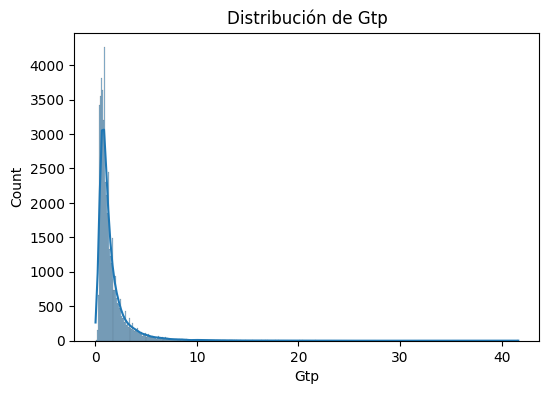

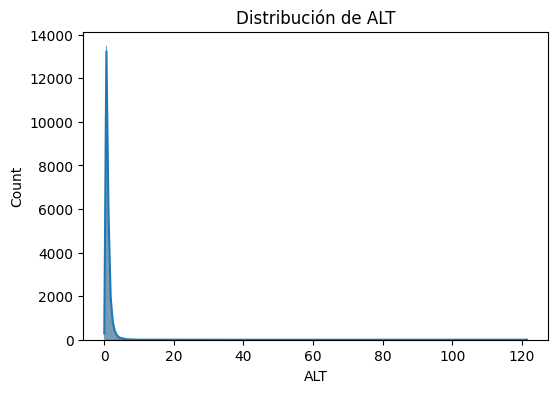

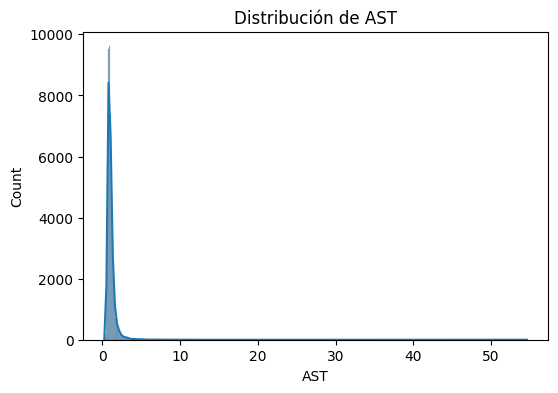

In [5]:
variables = ["Gtp", "ALT", "AST"]

for var in variables:
    plt.figure(figsize=(6,4))
    sns.histplot(train[var], kde=True)
    plt.title(f"Distribución de {var}")
    plt.show()

# Variable Gtp
- La variable Gtp presenta una distribución claramente asimétrica hacia la derecha, con una elevada concentración de observaciones en valores bajos y una cola extensa hacia valores altos.

- Este comportamiento coincide con lo observado previamente en el análisis descriptivo, donde la media resultó superior a la mediana.

- La forma de la distribución sugiere la posible presencia de valores extremos, aspecto que será analizado posteriormente mediante boxplots.

# Variable ALT
- La variable ALT presenta una distribución fuertemente asimétrica hacia la derecha, con una elevada concentración de observaciones en valores bajos y una cola extensa hacia valores elevados.

- La diferencia observada entre los percentiles superiores y el valor máximo sugiere la posible existencia de valores extremos, los cuales serán analizados mediante boxplots en las siguientes etapas del EDA.

# Variable AST
- La variable AST presenta distribuciones asimétricas positivas, caracterizadas por una elevada concentración de observaciones en valores bajos y colas extensas hacia valores elevados.

- Este comportamiento coincide con lo observado durante el análisis descriptivo y sugiere la posible presencia de valores extremos, los cuales serán evaluados mediante boxplots.


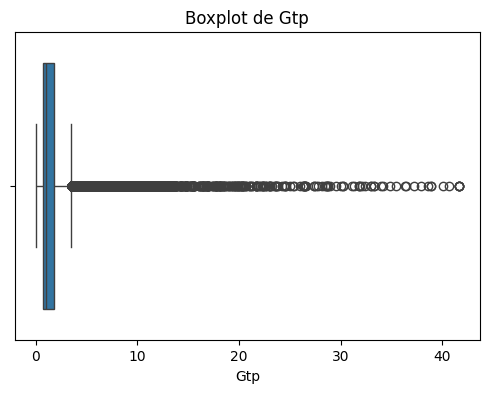

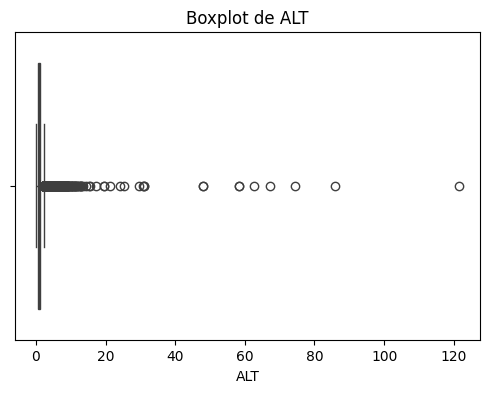

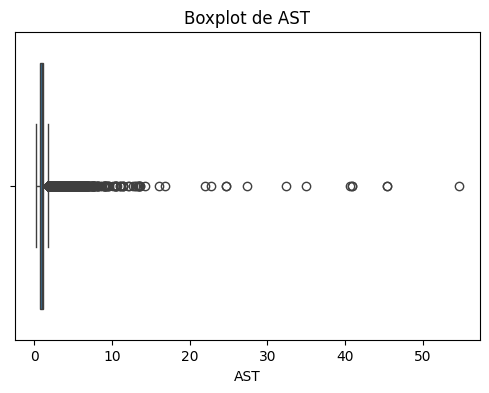

In [6]:
for var in variables:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=train[var])
    plt.title(f"Boxplot de {var}")
    plt.show()

# Variable Gtp
- La variable Gtp presenta una fuerte asimetría positiva. El boxplot evidencia una gran cantidad de valores atípicos hacia la derecha. Sin embargo, estos valores parecen corresponder al comportamiento natural de la variable y no necesariamente a errores de carga.

# Variable ALT
- La variable ALT presenta una fuerte asimetría positiva. El boxplot muestra una gran cantidad de valores atípicos hacia la derecha, incluyendo algunos extremadamente alejados del rango central. No obstante, estos valores parecen corresponder al comportamiento natural de la variable y no necesariamente a errores de registro.

# Variable AST
- La variable AST presenta una distribución fuertemente asimétrica hacia la derecha. El boxplot evidencia numerosos valores atípicos, aunque estos parecen corresponder al comportamiento natural de la variable y no necesariamente a errores de registro.



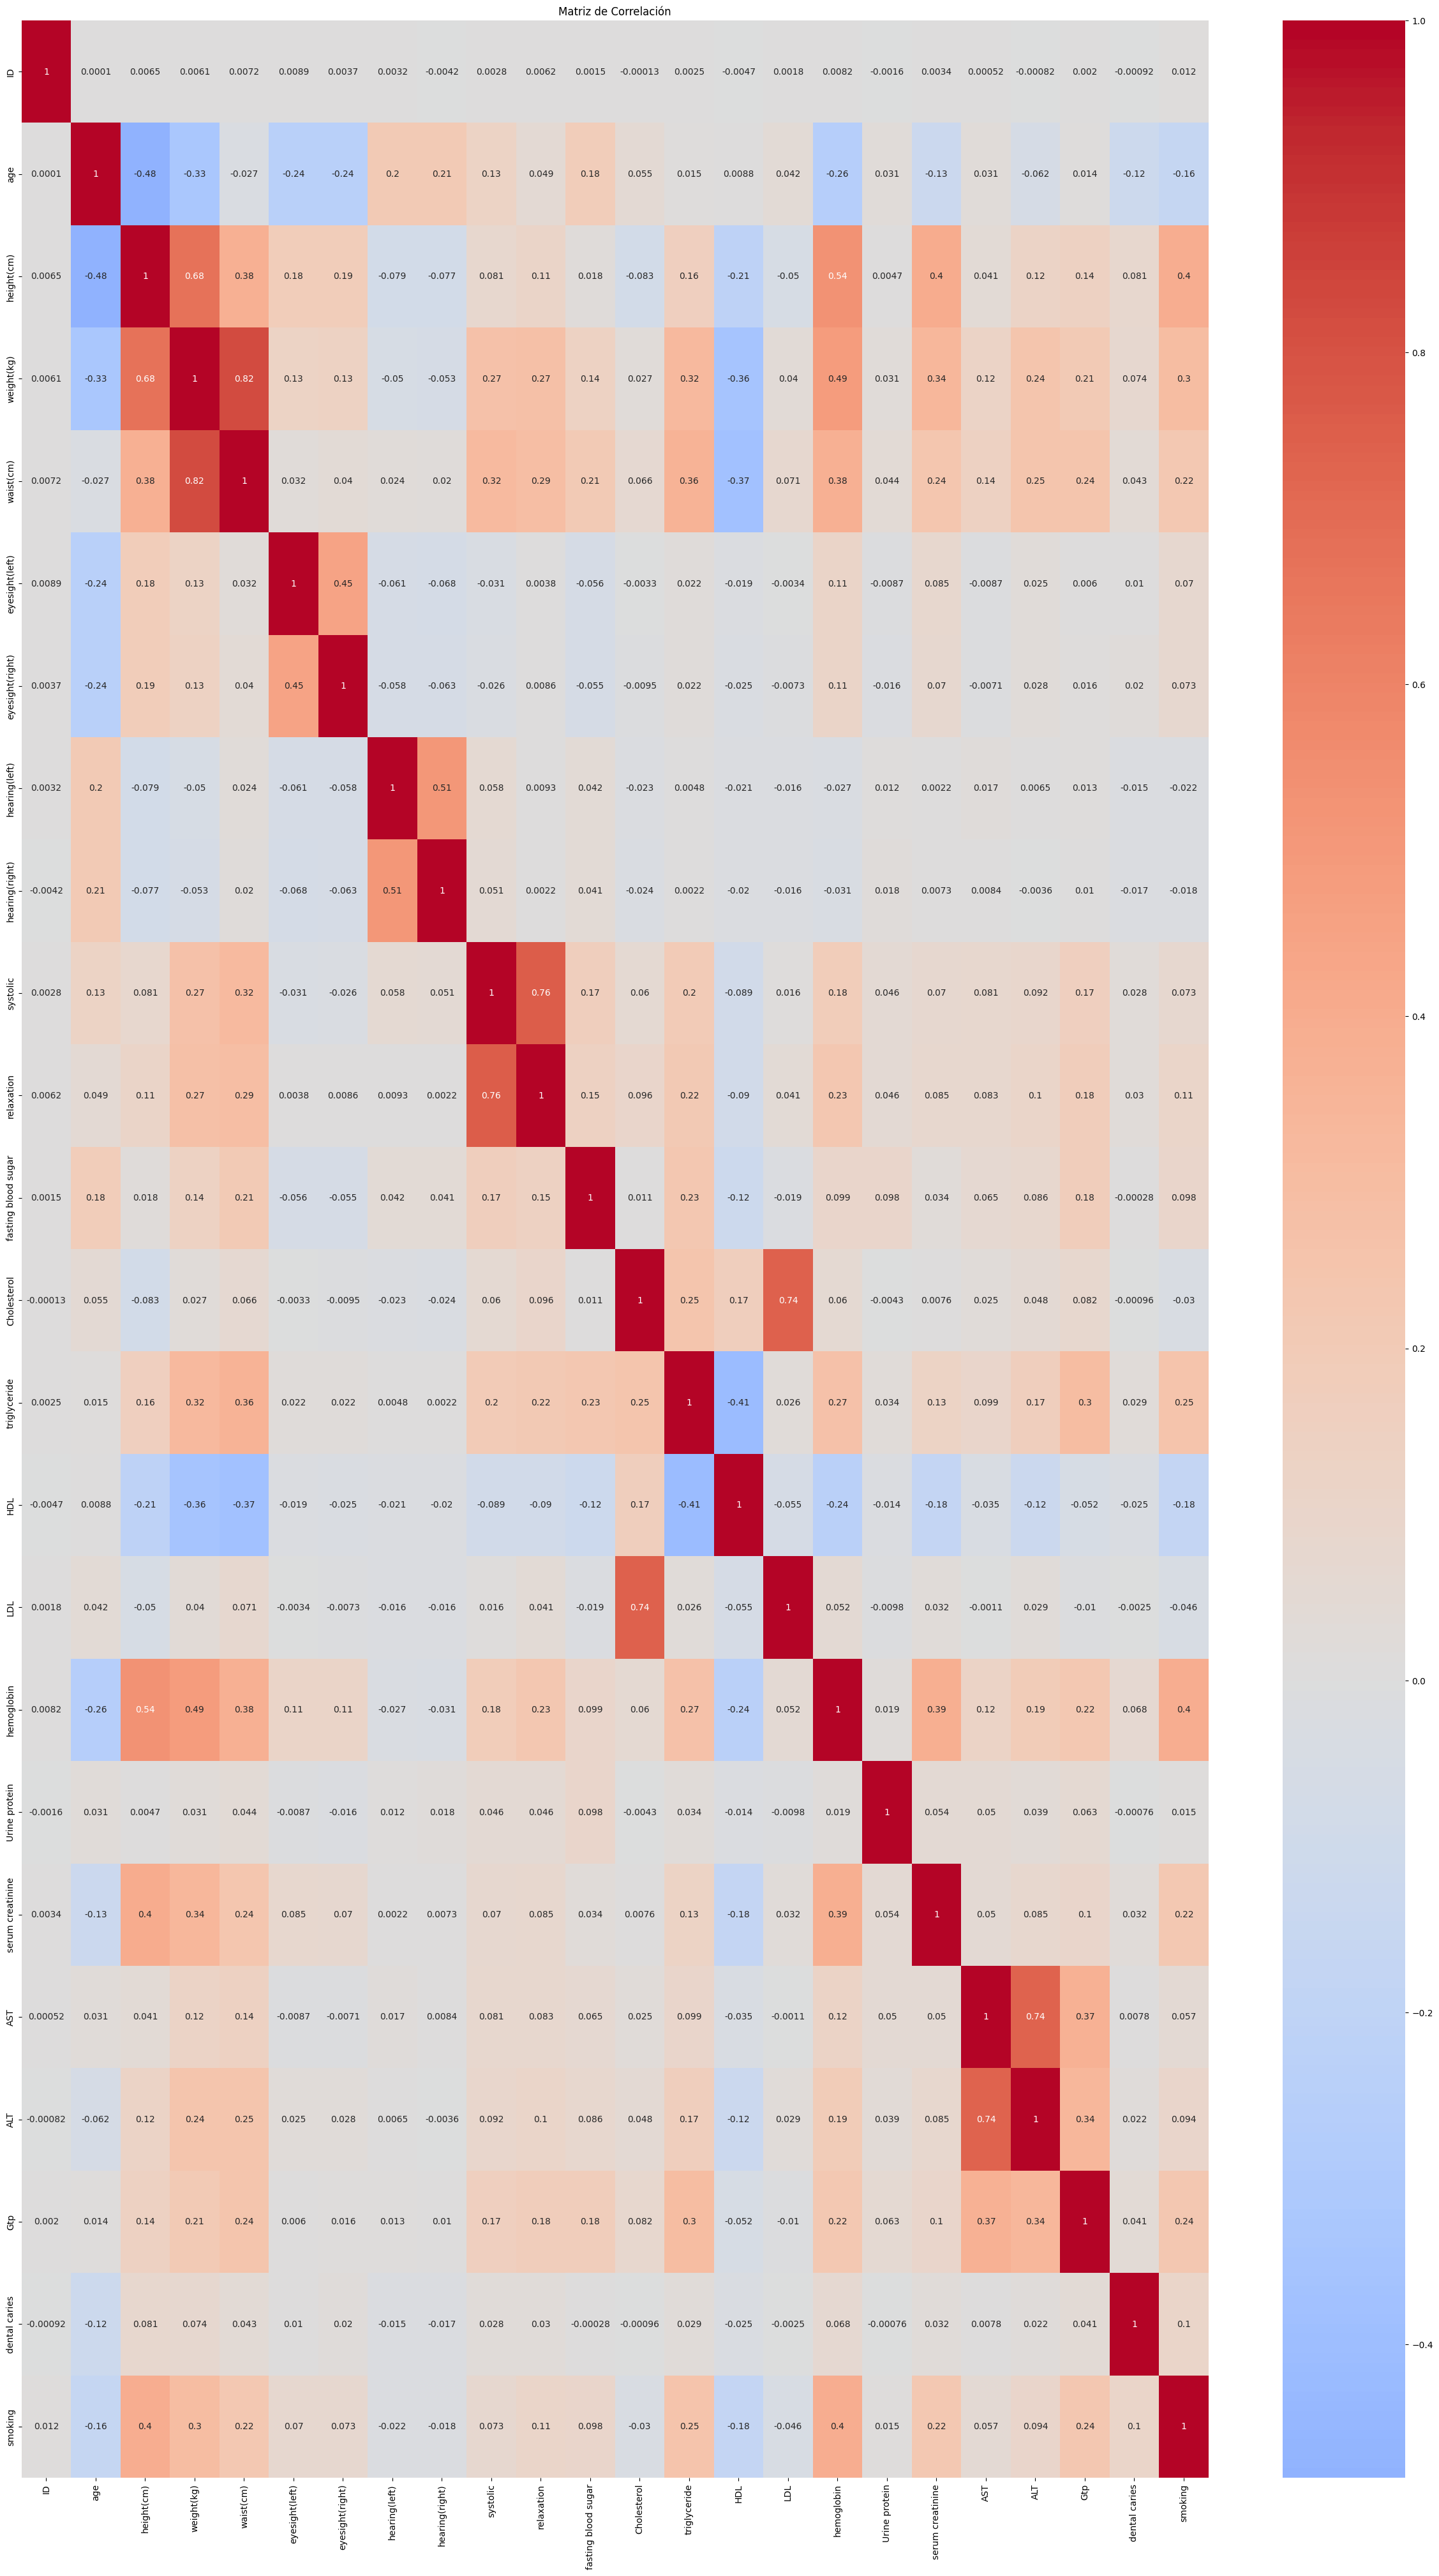

In [7]:
plt.figure(figsize=(30,50))

sns.heatmap(
    train.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlación")
plt.show()

# Hemoglobin 

- Muestra una correlación moderada positiva con la variable objetivo smoking (~0.40), por lo que también podría ser una variable relevante para el modelo.

<Axes: xlabel='smoking', ylabel='hemoglobin'>

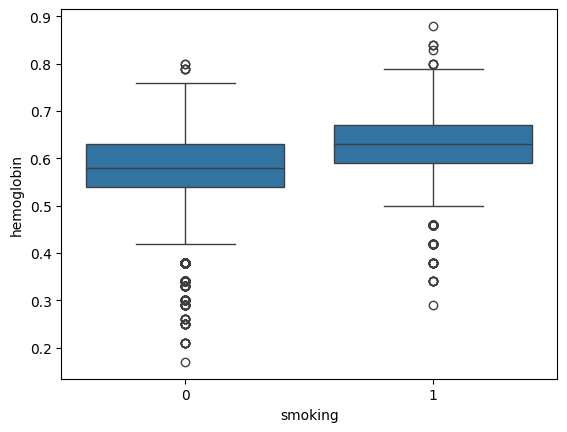

In [8]:
sns.boxplot(x='smoking', y='hemoglobin', data=train)

# Hemoglobin

- El análisis mediante boxplot muestra que los individuos fumadores presentan valores de hemoglobina superiores, en promedio, a los no fumadores. Si bien existe superposición entre ambos grupos, la diferencia observada coincide con la correlación positiva encontrada entre hemoglobin y smoking, sugiriendo que esta variable podría aportar capacidad predictiva al modelo.

# Hipótesis adicionales surgidas durante el EDA
- gender podría tener capacidad predictiva sobre smoking.

- tartar podría tener relación con smoking debido a posibles asociaciones con hábitos de salud bucal.

- dental caries también podría aportar información para la clasificación.

In [9]:
pd.crosstab(train['gender'], train['smoking'], normalize='index')

smoking,0,1
gender,,
F,0.957235,0.042765
M,0.447835,0.552165


# gender 
- Presenta una asociación muy marcada con la variable objetivo smoking. Mientras que el 95.7% de las mujeres del conjunto de entrenamiento son no fumadoras, en los hombres la proporción de fumadores alcanza aproximadamente el 55.2%. Esto sugiere que gender podría aportar una importante capacidad predictiva al modelo.

In [10]:
pd.crosstab(train['tartar'], train['smoking'], normalize='index')

smoking,0,1
tartar,,
N,0.687407,0.312593
Y,0.590270,0.409730


# tartar 
- Muestra una asociación moderada con la variable objetivo smoking. Los individuos con presencia de sarro presentan una proporción de fumadores cercana al 41%, frente al 31% observado en quienes no presentan sarro. Esto sugiere que la variable podría aportar información útil para el modelo predictivo, aunque con una fuerza menor a la observada en gender.

In [11]:
pd.crosstab(train['dental caries'], train['smoking'], normalize='index')

smoking,0,1
dental caries,,
0,0.65944,0.34056
1,0.53735,0.46265


# dental caries
- Se observa que los individuos con presencia de caries dentales presentan una mayor proporción de fumadores respecto de aquellos que no presentan caries. La diferencia observada es de aproximadamente 12 puntos porcentuales, lo que sugiere una asociación moderada entre ambas variables.

- Si bien esta relación es considerablemente menor a la observada para la variable gender, la variable dental caries podría aportar información útil para la predicción de la variable objetivo y no se considera candidata a eliminación en esta etapa del análisis.